In [1]:
pip install pydotplus


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install category_encoders


Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install graphviz


Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
import category_encoders as ce
import matplotlib.pyplot as plt
import pydotplus
from IPython.display import Image

In [7]:
data = pd.read_csv('car.csv')
print("Өгөгдлийн хэмжээ:", data.shape)
data.head()


Өгөгдлийн хэмжээ: (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [9]:
print(data.dtypes)

buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
class       object
dtype: object


In [11]:
duplicate_count = data.duplicated().sum()
print(duplicate_count)

0


In [13]:
print(data.isnull().sum())

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


In [16]:
X = data.drop(['class'], axis=1)
Y = data['class']


In [19]:
encoder = ce.OrdinalEncoder(cols=X.columns)
X_encoded = encoder.fit_transform(X)
print(X_encoded.head())

   buying  maint  doors  persons  lug_boot  safety
0       1      1      1        1         1       1
1       1      1      1        1         1       2
2       1      1      1        1         1       3
3       1      1      1        1         2       1
4       1      1      1        1         2       2


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, Y,
    test_size=0.33,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1157, 6)
X_test shape: (571, 6)


In [34]:
clf = DecisionTreeClassifier(criterion='gini',max_depth=6, random_state=42)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


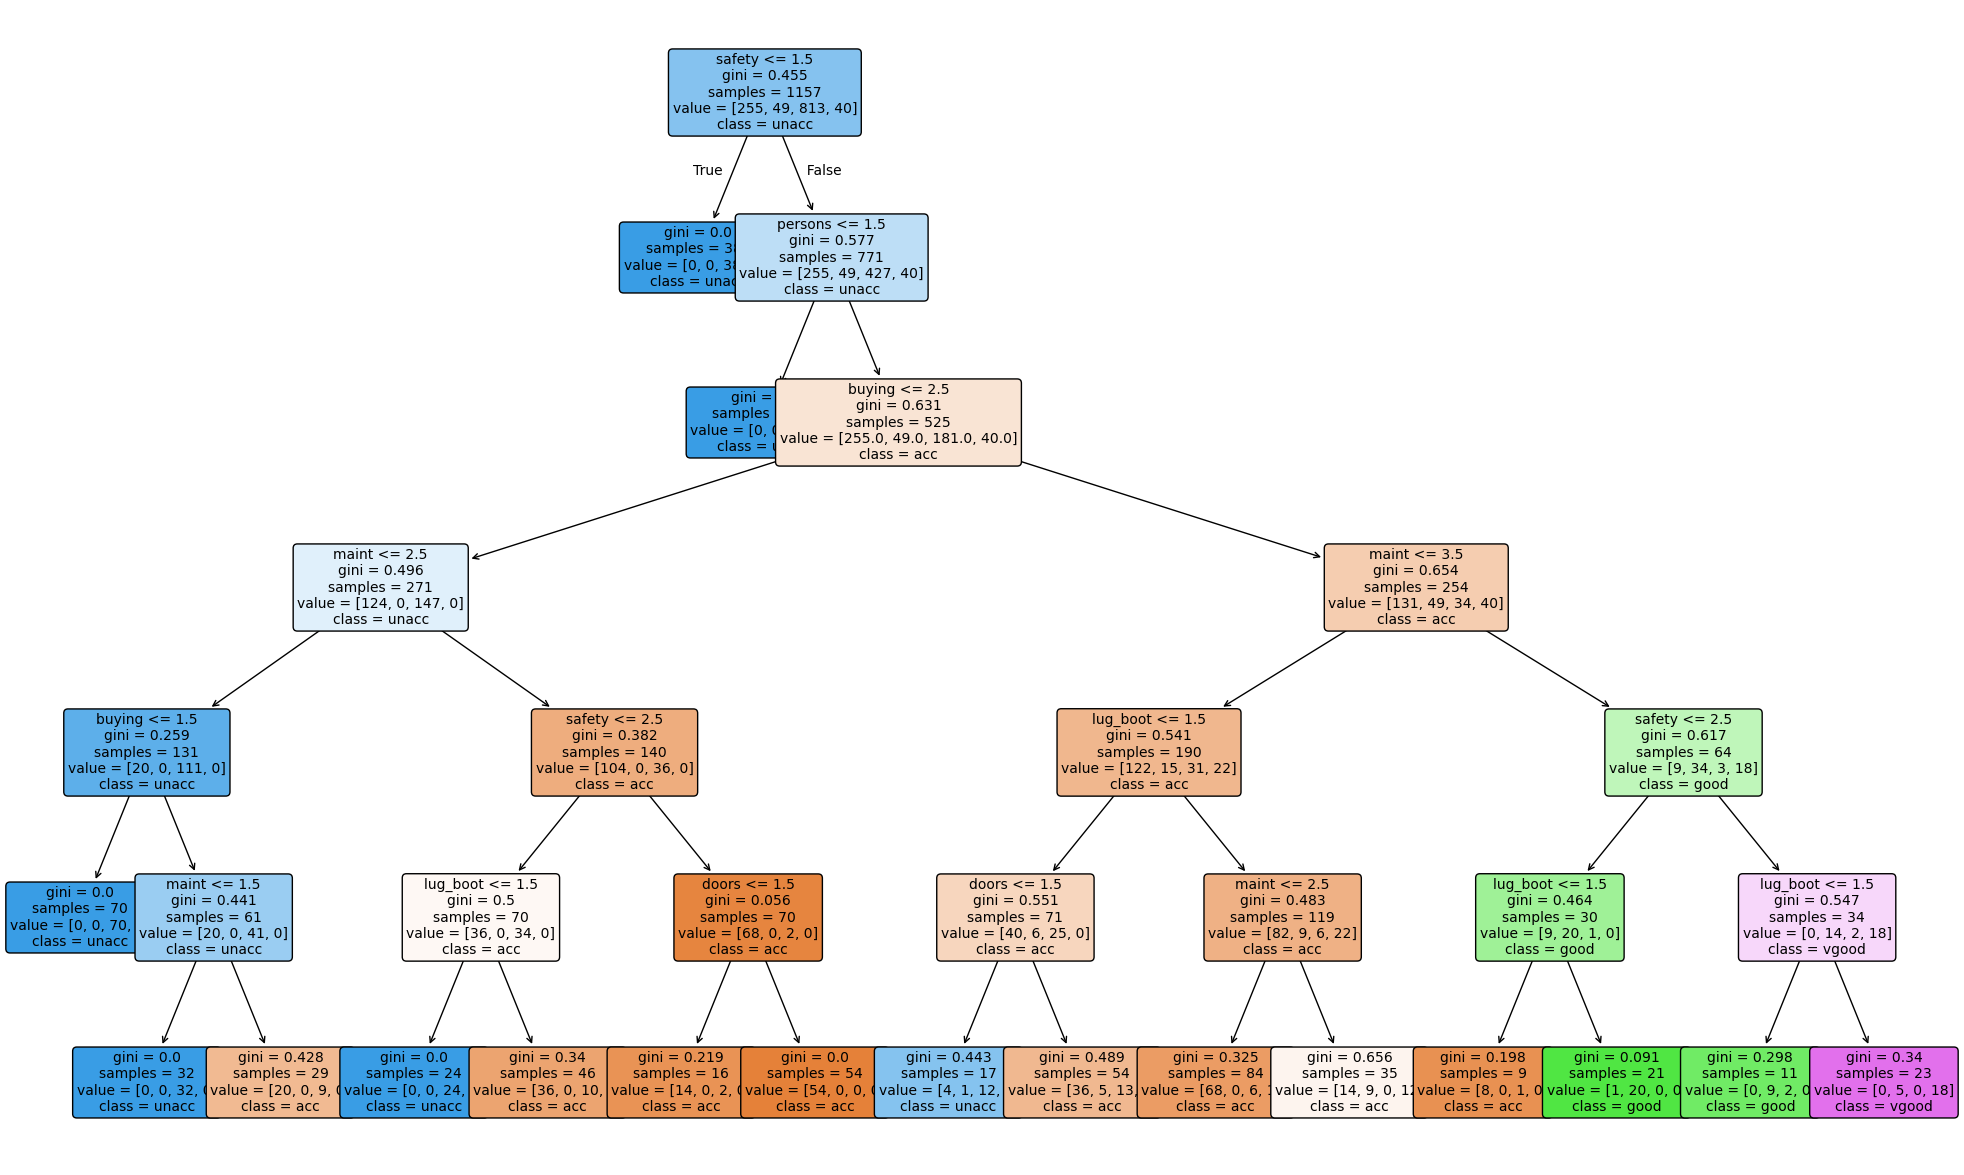

In [35]:
plt.figure(figsize=(25, 15))
tree.plot_tree(
    clf,
    feature_names=X_train.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [32]:
y_pred = clf.predict(X_test)
print(y_pred[:10])

['unacc' 'good' 'unacc' 'acc' 'unacc' 'acc' 'unacc' 'unacc' 'acc' 'unacc']


In [38]:
acc = accuracy_score(y_test, y_pred)
print(acc*100)


91.06830122591944
